<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/Best%20Candidate%20Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
import glob

print("Best Candidate Review – Week 4")
print("Notebook started successfully.")

Best Candidate Review – Week 4
Notebook started successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print("Uploaded file:", zip_file)

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip
Uploaded file: Underwater-Image-Data-set-main.zip


In [3]:
import zipfile
import glob
import os

extract_path = "/content/best_review_data"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

csv_files = glob.glob(
    extract_path + "/**/*.csv",
    recursive=True
)

print("CSV files found:", len(csv_files))

for f in csv_files:
    print(os.path.basename(f))

CSV files found: 8
training_log 2.csv
training_log 4.csv
training_log 6.csv
training_log 8.csv
training_log 1.csv
training_log 5.csv
training_log 7.csv
training_log 3.csv


In [4]:
all_logs = []

for f in csv_files:
    temp = pd.read_csv(f)
    temp["source_file"] = os.path.basename(f)
    all_logs.append(temp)

df = pd.concat(all_logs, ignore_index=True)

print("Combined dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nSamples per training run:")
print(df["source_file"].value_counts())

Combined dataset shape: (24915, 6)

Columns:
['epoch', 'step', 'gen_total', 'disc_loss', 'time_s', 'source_file']

Samples per training run:
source_file
training_log 4.csv    3900
training_log 7.csv    3900
training_log 5.csv    3900
training_log 1.csv    3900
training_log 3.csv    3900
training_log 2.csv    3660
training_log 6.csv    1521
training_log 8.csv     234
Name: count, dtype: int64


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df[["epoch", "step", "gen_total", "disc_loss", "time_s"]].describe())

Missing values:
epoch          0
step           0
gen_total      0
disc_loss      0
time_s         0
source_file    0
dtype: int64

Duplicate rows: 0

Basic statistics:


,epoch,step,gen_total,disc_loss,time_s
count,24915.000000,24915.000000,24915.000000,24915.000000,24915.000000
mean,52.333935,1835.712462,13.347087,0.551729,96.163017
std,29.743196,1129.729162,7.621047,0.292557,213.210639
min,1.000000,1.000000,3.235735,0.020976,4.876095
25%,27.000000,850.000000,7.840670,0.418167,45.790789
50%,53.000000,1776.000000,11.780836,0.548061,79.022856
75%,77.000000,2814.000000,16.629889,0.655409,112.391965
max,136.000000,3900.000000,90.369987,11.538145,7865.182561


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
features = ["epoch", "step", "disc_loss", "time_s"]
target = "gen_total"

X = df[features].values
y = df[target].values

# Time-ordered split: 70% train, 15% validation, 15% test
n = len(X)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train_base = X[:train_end]
y_train_base = y[:train_end]

X_val_base = X[train_end:val_end]
y_val_base = y[train_end:val_end]

X_test_base = X[val_end:]
y_test_base = y[val_end:]

# Train baseline
baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train_base)

# Test prediction
baseline_pred = baseline_model.predict(X_test_base)

# Metrics
baseline_mae = mean_absolute_error(y_test_base, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test_base, baseline_pred))
baseline_mape = np.mean(
    np.abs((y_test_base - baseline_pred) /
           np.maximum(np.abs(y_test_base), 1e-8))
) * 100
baseline_r2 = r2_score(y_test_base, baseline_pred)

print("Baseline Linear Regression Results")
print("-----------------------------------")
print("MAE  :", baseline_mae)
print("RMSE :", baseline_rmse)
print("MAPE :", baseline_mape, "%")
print("R²   :", baseline_r2)

Baseline Linear Regression Results
-----------------------------------
MAE  : 3.0906413789098717
RMSE : 4.0316364120217205
MAPE : 25.324475872250552 %
R²   : -0.401078659356501


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Sequence settings
SEQUENCE_LENGTH = 10

# Create sequences
X_all = df[features].values
y_all = df[target].values

X_seq = []
y_seq = []

for i in range(len(X_all) - SEQUENCE_LENGTH):
    X_seq.append(X_all[i:i + SEQUENCE_LENGTH])
    y_seq.append(y_all[i + SEQUENCE_LENGTH])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Time-ordered split
n = len(X_seq)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]

X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

# Training-only normalization
scaler = StandardScaler()

scaler.fit(
    X_train.reshape(-1, X_train.shape[-1])
)

X_train = scaler.transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_val = scaler.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

X_test = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# TCN model
class TCNModel(nn.Module):
    def __init__(self, input_size, hidden_channels=64, dropout=0.0):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv1d(
                input_size,
                hidden_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Conv1d(
                hidden_channels,
                hidden_channels,
                kernel_size=3,
                padding=2,
                dilation=2
            ),
            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Conv1d(
                hidden_channels,
                32,
                kernel_size=3,
                padding=4,
                dilation=4
            ),
            nn.ReLU()
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.network(x)
        x = x[:, :, -1]
        return self.fc(x)


# Best tuned configuration
model = TCNModel(
    input_size=X_train.shape[2],
    hidden_channels=64,
    dropout=0.0
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=32,
    shuffle=False
)

print("Tuned TCN created successfully.")
print("Hidden channels: 64")
print("Dropout: 0.0")
print("Learning rate: 0.0005")
print("Batch size: 32")
print("Sequence length: 10")

Tuned TCN created successfully.
Hidden channels: 64
Dropout: 0.0
Learning rate: 0.0005
Batch size: 32
Sequence length: 10


In [8]:
import time

epochs = 15
best_val_loss = float("inf")
train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(epochs):

    # Training
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        predictions = model(xb)
        loss = criterion(predictions, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:

            predictions = model(xb)
            loss = criterion(predictions, yb)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

runtime = time.time() - start_time

print("\nTraining completed!")
print("Best validation loss:", best_val_loss)
print("Training time:", round(runtime, 2), "seconds")

Epoch 01/15 | Train Loss: 105.3180 | Val Loss: 65.7196
Epoch 02/15 | Train Loss: 37.5087 | Val Loss: 54.2322
Epoch 03/15 | Train Loss: 34.4967 | Val Loss: 47.2468
Epoch 04/15 | Train Loss: 32.9255 | Val Loss: 45.6183
Epoch 05/15 | Train Loss: 31.8792 | Val Loss: 44.1972
Epoch 06/15 | Train Loss: 31.2444 | Val Loss: 42.6748
Epoch 07/15 | Train Loss: 30.6164 | Val Loss: 42.8834
Epoch 08/15 | Train Loss: 30.5255 | Val Loss: 42.6150
Epoch 09/15 | Train Loss: 30.1582 | Val Loss: 42.5799
Epoch 10/15 | Train Loss: 30.0243 | Val Loss: 43.0388
Epoch 11/15 | Train Loss: 30.1436 | Val Loss: 43.8090
Epoch 12/15 | Train Loss: 29.8479 | Val Loss: 44.2280
Epoch 13/15 | Train Loss: 29.8220 | Val Loss: 43.1893
Epoch 14/15 | Train Loss: 29.6009 | Val Loss: 44.2839
Epoch 15/15 | Train Loss: 29.2990 | Val Loss: 44.6429

Training completed!
Best validation loss: 42.57991825005947
Training time: 64.35 seconds


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()

with torch.no_grad():
    tuned_pred = model(X_test_tensor).numpy().flatten()

tuned_true = y_test_tensor.numpy().flatten()

tuned_mae = mean_absolute_error(tuned_true, tuned_pred)
tuned_rmse = np.sqrt(
    mean_squared_error(tuned_true, tuned_pred)
)

tuned_mape = np.mean(
    np.abs(
        (tuned_true - tuned_pred) /
        np.maximum(np.abs(tuned_true), 1e-8)
    )
) * 100

tuned_r2 = r2_score(tuned_true, tuned_pred)

print("Tuned TCN Test Results")
print("---------------------------")
print("MAE  :", tuned_mae)
print("RMSE :", tuned_rmse)
print("MAPE :", tuned_mape, "%")
print("R²   :", tuned_r2)

Tuned TCN Test Results
---------------------------
MAE  : 2.3336870670318604
RMSE : 3.04130052078499
MAPE : 18.198092 %
R²   : 0.1988620162010193


In [10]:
comparison_table = pd.DataFrame([
    {
        "Model": "Linear Regression Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "MAPE (%)": baseline_mape,
        "R2": baseline_r2
    },
    {
        "Model": "Tuned TCN",
        "MAE": tuned_mae,
        "RMSE": tuned_rmse,
        "MAPE (%)": tuned_mape,
        "R2": tuned_r2
    }
])

print("Baseline vs Tuned Model")
display(comparison_table)

Baseline vs Tuned Model


,Model,MAE,RMSE,MAPE (%),R2
0,Linear Regression Baseline,3.090641,4.031636,25.324476,-0.401079
1,Tuned TCN,2.333687,3.041301,18.198092,0.198862


In [11]:
# Create prediction analysis table
prediction_analysis = pd.DataFrame({
    "Actual": tuned_true,
    "Predicted": tuned_pred
})

prediction_analysis["Absolute_Error"] = np.abs(
    prediction_analysis["Actual"] -
    prediction_analysis["Predicted"]
)

# Best predictions = smallest errors
best_cases = prediction_analysis.sort_values(
    "Absolute_Error"
).head(5)

# Worst predictions = largest errors
worst_cases = prediction_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(5)

print("Representative Successful Predictions")
print("--------------------------------------")
display(best_cases)

print("\nRepresentative Failure Cases")
print("--------------------------------------")
display(worst_cases)

Representative Successful Predictions
--------------------------------------


,Actual,Predicted,Absolute_Error
2107,9.605797,9.605316,0.000481
3702,10.281474,10.280890,0.000585
1929,10.474861,10.475588,0.000727
771,13.988107,13.989198,0.001091
3399,9.330568,9.328508,0.002060



Representative Failure Cases
--------------------------------------


,Actual,Predicted,Absolute_Error
3491,24.754225,10.223300,14.530925
3579,19.278000,6.198107,13.079893
3735,22.243809,10.172315,12.071494
2270,20.971518,9.451786,11.519732
2994,19.913315,8.658571,11.254744


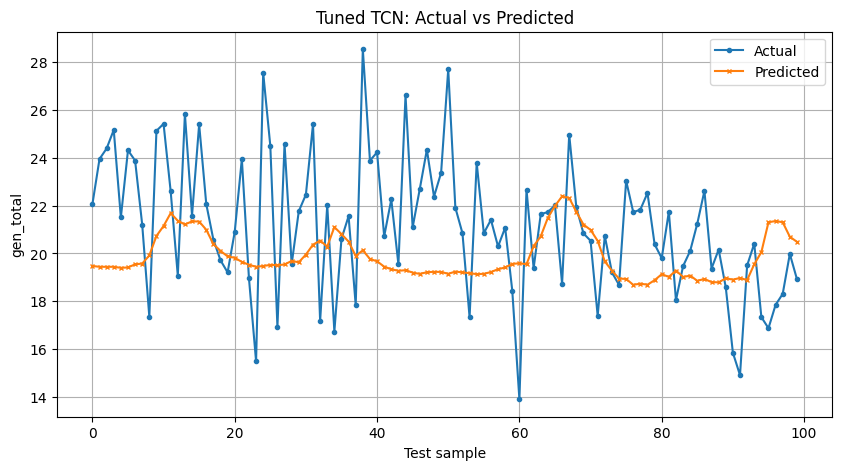

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    tuned_true[:100],
    label="Actual",
    marker="o",
    markersize=3
)

plt.plot(
    tuned_pred[:100],
    label="Predicted",
    marker="x",
    markersize=3
)

plt.xlabel("Test sample")
plt.ylabel("gen_total")
plt.title("Tuned TCN: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Calculate error statistics
errors = tuned_true - tuned_pred
absolute_errors = np.abs(errors)

print("Error Analysis")
print("----------------------------")
print("Mean absolute error:", np.mean(absolute_errors))
print("Maximum error:", np.max(absolute_errors))
print("Minimum error:", np.min(absolute_errors))
print("Error standard deviation:", np.std(errors))

# Find unusually large errors
error_threshold = np.percentile(absolute_errors, 95)

unusual_errors = prediction_analysis[
    prediction_analysis["Absolute_Error"] >= error_threshold
].copy()

print("\n95th-percentile error threshold:", error_threshold)
print("Number of unusual error cases:", len(unusual_errors))

print("\nLargest error cases:")
display(
    unusual_errors.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)

Error Analysis
----------------------------
Mean absolute error: 2.333687
Maximum error: 14.530925
Minimum error: 0.00048065186
Error standard deviation: 2.867574

95th-percentile error threshold: 5.9545937
Number of unusual error cases: 187

Largest error cases:


,Actual,Predicted,Absolute_Error
3491,24.754225,10.223300,14.530925
3579,19.278000,6.198107,13.079893
3735,22.243809,10.172315,12.071494
2270,20.971518,9.451786,11.519732
2994,19.913315,8.658571,11.254744
2124,17.607649,6.368268,11.239380
1935,19.898399,8.703415,11.194984
3583,16.444281,5.467280,10.977000
3008,20.543194,9.616546,10.926648
2705,20.818750,9.904623,10.914127
